# Monocular Metric Depth Estimation with Depth Pro

This notebook evaluates **Apple's Depth Pro** for zero-shot monocular metric depth estimation under a real-world indoor evaluation setup.

In AI and robotics, monocular metric depth estimation provides spatial and geometric information from a single camera, supporting applications such as autonomous navigation, obstacle detection, scene understanding, and 3D perception without requiring a dedicated depth sensor.

Depth Pro predicts dense metric depth from a single RGB image and estimates camera focal length. The experiment evaluates metric accuracy using **59 synchronized RGB-depth pairs captured with an Intel RealSense depth camera in a real indoor laboratory environment**.

For each frame:

- The **RGB image** is the sole input to Depth Pro.
- The corresponding **RealSense depth map** is used as independent, dense, per-pixel ground truth and is never provided to the model.
- RealSense depth values are stored as 16-bit values in millimeters and converted to meters using a scale factor of `0.001`.

The primary metrics are Mean Absolute Error (MAE), Root Mean Square Error (RMSE), Absolute Relative Error (Abs Rel %), median depth error, predicted-depth standard deviation, inference time, and focal-length consistency.


In [ ]:
!pip install -q torch torchvision pillow matplotlib numpy pandas huggingface-hub

**Restart the session after running the below cell**

In [ ]:
!rm -rf /content/ml-depth-pro
!git clone -q https://github.com/apple/ml-depth-pro.git
%cd /content/ml-depth-pro
!pip install -q -e .
!pip install -q "numpy>=2.0,<2.3"
%cd /content
# RESTART THE RUNTIME AND RUN AGAIN FROM BELOW CELL

/content/ml-depth-pro
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 70.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... canceled
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
        reqs, check_supported_wheels=not opti

In [ ]:
!mkdir -p checkpoints
!hf download apple/DepthPro depth_pro.pt --local-dir checkpoints
!ls -lh checkpoints/depth_pro.pt
%cd /content/ml-depth-pro

In [ ]:
!huggingface-cli download --local-dir checkpoints apple/DepthPro
%cd ..

In [ ]:
import gc
import time
import zipfile
from pathlib import Path

import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from PIL import Image
from huggingface_hub import hf_hub_download

import depth_pro

In [ ]:
CHECKPOINT_PATH = Path(
    "/content/ml-depth-pro/checkpoints/depth_pro.pt"
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")
print(f"Checkpoint exists: {CHECKPOINT_PATH.exists()}")
print(f"Checkpoint path: {CHECKPOINT_PATH}")

## Test Dataset

The evaluation dataset was captured directly in a real laboratory environment using an Intel RealSense RGB-D camera.

For every frame, the dataset provides a synchronized RGB image and corresponding dense RealSense depth map:

- **`color/`** — RGB image used as the sole input to Depth Pro.
- **`depth/`** — 16-bit RealSense depth map providing dense per-pixel ground truth.

The stored RealSense depth values are in millimeters and are converted to meters using a scale factor of **0.001**.

The complete dataset contains **59 RGB-depth pairs**, zipped and uploaded to a Hugging Face dataset repository. All pairs are loaded the same way and evaluated identically — the only thing that should need changing if the capture set is extended is the zip contents on Hugging Face.

The RealSense depth map is never provided to the model during inference. It is used only for quantitative evaluation.


In [ ]:
HF_REPO = "WasiqSaleem/Portfolio_Assets"
HF_REPO_TYPE = "dataset"
ZIP_NAME = "testing_env_spec_real_camera_dataset_combined.zip"
DATASET_FOLDER = "testing_env_spec_real_camera_dataset_combined"  # top-level folder inside the zip
COLOR_SUBDIR = "color"
DEPTH_SUBDIR = "depth"

# RealSense depth PNGs are stored in millimeters -> convert to meters.
DEPTH_UNITS_TO_METERS = 0.001

In [ ]:
ZIP_PATH = hf_hub_download(
    repo_id=HF_REPO,
    filename=ZIP_NAME,
    repo_type=HF_REPO_TYPE,
    local_dir="/content",
)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall("/content")

DATASET_ROOT = Path("/content") / DATASET_FOLDER
COLOR_DIR = DATASET_ROOT / COLOR_SUBDIR
DEPTH_DIR = DATASET_ROOT / DEPTH_SUBDIR

color_files = sorted(COLOR_DIR.glob("*.png"))
depth_files = sorted(DEPTH_DIR.glob("*.png"))

assert len(color_files) == len(depth_files) and all(
    c.stem == d.stem for c, d in zip(color_files, depth_files)
), "color/ and depth/ frames are not aligned by filename."

print(f"Verified {len(color_files)} RGB-depth pairs.")


In [ ]:
available_cases = [
    {
        "image_number": c.stem,
        "filename": c.name,
        "image_path": c,
        "depth_path": d,
        "image": Image.open(c).convert("RGB"),
    }
    for c, d in zip(color_files, depth_files)
]

print(f"Loaded {len(available_cases)} RGB-depth pairs.")

sample_depth = np.array(Image.open(available_cases[0]["depth_path"]), dtype=np.float32)
valid = sample_depth[sample_depth > 0]
print(
    f"Depth range: {valid.min():.0f}-{valid.max():.0f} raw "
    f"= {valid.min() * DEPTH_UNITS_TO_METERS:.3f}-{valid.max() * DEPTH_UNITS_TO_METERS:.3f} m"
)


In [ ]:
sample_cases = available_cases[:: max(1, len(available_cases) // 6)][:6] if available_cases else []

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, case in zip(axes.flat, sample_cases):
    ax.imshow(case["image"])
    ax.set_title(case["image_number"])
    ax.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, case in zip(axes.flat, sample_cases):
    gt = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    im = ax.imshow(gt, cmap="magma")
    ax.set_title(f"{case['image_number']} - RealSense GT")
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Showing {len(sample_cases)} of {len(available_cases)} loaded frames.")


## Evaluation Method

For each RGB image, Depth Pro produces a dense metric depth map, which is resized to match the RealSense depth-map resolution.

Because ground truth is now a **dense per-pixel RealSense depth map** rather than a single measured distance, evaluation is performed **pixel-by-pixel** over every valid (nonzero, finite) location shared by the prediction and the ground truth:

$$MAE = \frac{1}{N}\sum |\hat{d}_i - d_{GT,i}|$$

$$RMSE = \sqrt{\frac{1}{N}\sum (\hat{d}_i - d_{GT,i})^2}$$

$$\text{Abs Rel} = \frac{1}{N}\sum \frac{|\hat{d}_i - d_{GT,i}|}{d_{GT,i}} \times 100$$

The **median predicted depth** and **median RealSense depth** are also retained per frame as a robust image-level summary, and the predicted-depth standard deviation characterizes spatial consistency.


In [ ]:
def evaluate_depth(depth_map, ground_truth):
    depth_map = np.asarray(depth_map, dtype=np.float32)
    ground_truth = np.asarray(ground_truth, dtype=np.float32)

    valid = (
        np.isfinite(depth_map)
        & np.isfinite(ground_truth)
        & (depth_map > 0)
        & (ground_truth > 0)
    )

    pred = depth_map[valid]
    gt = ground_truth[valid]

    if pred.size == 0:
        raise ValueError("No valid overlapping pixels between prediction and ground truth.")

    error = np.abs(pred - gt)

    return {
        "GT Median (m)": float(np.median(gt)),
        "Pred Median (m)": float(np.median(pred)),
        "Pred Mean (m)": float(np.mean(pred)),
        "Std Depth (m)": float(np.std(pred)),
        "MAE (m)": float(np.mean(error)),
        "RMSE (m)": float(np.sqrt(np.mean((pred - gt) ** 2))),
        "Abs Rel (%)": float(np.mean(error / gt) * 100),
        "Median Absolute Error (m)": float(np.median(error)),
        "Valid Pixels (%)": float(valid.mean() * 100),
    }


## Depth Pro Model

The pretrained Depth Pro model and preprocessing transform are loaded once and reused for all 59 test frames.

The RealSense ground-truth depth map is not supplied to the model.


In [ ]:
model, transform = depth_pro.create_model_and_transforms()

model = model.to(device)
model.eval()

print("Depth Pro loaded successfully.")

In [ ]:
depthpro_results = []
depthpro_depth_maps = {}
depthpro_focal_lengths = {}
depthpro_inference_times = {}

## Inference

For every frame, the RGB image is processed using the official Depth Pro preprocessing pipeline.

The model output contains dense metric depth and a focal-length estimate. The predicted depth map is resized to the RealSense depth-map resolution and compared pixel-by-pixel against the RealSense ground truth.


In [ ]:
for case in available_cases:
    image_rgb, _, f_px = depth_pro.load_rgb(
        case["image_path"]
    )

    image_tensor = transform(image_rgb)
    if isinstance(image_tensor, torch.Tensor):
        image_tensor = image_tensor.to(device)

    start_time = time.perf_counter()

    with torch.inference_mode():
        prediction = model.infer(
            image_tensor, f_px=f_px
        )

    inference_time = time.perf_counter() - start_time

    depth = prediction["depth"]
    focal_length = prediction.get(
        "focallength_px", np.nan
    )

    if isinstance(focal_length, torch.Tensor):
      focal_length = focal_length.detach().cpu().item()

    depth_np = (
        depth.detach().cpu().numpy()
    )

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    depth_np = cv2.resize(
        depth_np, (gt_depth.shape[1], gt_depth.shape[0]), interpolation=cv2.INTER_LINEAR
    )

    metrics = evaluate_depth(
        depth_np, gt_depth
    )
    result = {
        "Image": case["image_number"],
        "Filename": case["filename"],
        "Model": "Depth Pro",
        "Inference Time (s)": inference_time,
        "Estimated Focal Length (px)": (
            float(focal_length)
            if np.isfinite(focal_length)
            else np.nan
        ),
        **metrics
    }

    depthpro_results.append(result)
    key = case["image_number"]

    depthpro_depth_maps[key] = depth_np
    depthpro_focal_lengths[key] = focal_length
    depthpro_inference_times[key] = inference_time

    print(
        f"Frame {case['image_number']} | "
        f"GT Median = {metrics['GT Median (m)']:.3f} m | "
        f"Pred Median = {metrics['Pred Median (m)']:.3f} m | "
        f"Abs Rel = {metrics['Abs Rel (%)']:.2f}% | "
        f"Time = {inference_time:.3f}s"
    )


## Image-Level Quantitative Results

Each of the 59 RGB-depth frames is treated as an independent test sample, evaluated densely against its own RealSense ground-truth depth map.


In [ ]:
depthpro_df = pd.DataFrame(depthpro_results)
display(depthpro_df)

## Depth Map Visualization

A sample of frames is shown with the RGB image, the RealSense ground-truth depth map, and the Depth Pro prediction side by side for qualitative inspection. All 59 frames are still used in the quantitative analysis above and below — only the plotted sample is limited for readability.


In [ ]:
sample_cases = available_cases[:: max(1, len(available_cases) // 5)][:5] if available_cases else []

for case in sample_cases:
    key = case["image_number"]

    depth_map = depthpro_depth_maps[key]
    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    result = depthpro_df[depthpro_df["Image"] == case["image_number"]].iloc[0]

    fig, axes = plt.subplots(
        1, 3, figsize=(19, 6)
    )

    axes[0].imshow(case["image"])
    axes[0].set_title(
        f"RGB Image\n"
        f"Frame {case['image_number']}"
    )
    axes[0].axis("off")

    im_gt = axes[1].imshow(
        gt_depth, cmap="magma"
    )
    axes[1].set_title(
        f"RealSense Ground Truth\n"
        f"Median = {result['GT Median (m)']:.3f} m"
    )
    axes[1].axis("off")
    fig.colorbar(im_gt, ax=axes[1], fraction=0.046, pad=0.04)

    im = axes[2].imshow(
        depth_map, cmap="magma"
    )
    axes[2].set_title(
        f"Depth Pro Metric Depth\n"
        f"Median = {result['Pred Median (m)']:.3f} m"
    )
    axes[2].axis("off")

    cbar = fig.colorbar(
        im, ax=axes[2],
        fraction=0.046, pad=0.04
    )
    cbar.set_label("Depth (m)")

    plt.tight_layout()
    plt.show()


## Accuracy Summary Across the Dataset

Unlike a fixed-distance experiment, this dataset contains 59 frames spanning naturally varying scene depths captured across the laboratory environment, so there is no meaningful "per-distance" grouping.

Instead, the per-frame metrics are aggregated into a single dataset-wide accuracy summary.


In [ ]:
accuracy_summary = pd.DataFrame([{
    "Samples": len(depthpro_df),
    "Mean Pred Median (m)": depthpro_df["Pred Median (m)"].mean(),
    "Mean GT Median (m)": depthpro_df["GT Median (m)"].mean(),
    "Mean MAE (m)": depthpro_df["MAE (m)"].mean(),
    "Mean RMSE (m)": depthpro_df["RMSE (m)"].mean(),
    "Mean Abs Rel (%)": depthpro_df["Abs Rel (%)"].mean(),
    "Mean Surface Std (m)": depthpro_df["Std Depth (m)"].mean(),
    "Mean Inference Time (s)": depthpro_df["Inference Time (s)"].mean(),
}])

display(accuracy_summary)


## Predicted Depth vs Ground Truth

The ideal metric-depth estimator follows:

$$\hat{d}=d_{GT}$$

Each point is one of the 59 frames, comparing its median predicted depth against its median RealSense ground-truth depth. The closer the points are to the identity line, the better the metric-depth accuracy.


In [ ]:
plt.figure(figsize=(8, 7))

plt.scatter(
    depthpro_df["GT Median (m)"],
    depthpro_df["Pred Median (m)"],
    s=25, alpha=0.7, label="Depth Pro"
)

max_value = max(
    depthpro_df["GT Median (m)"].max(),
    depthpro_df["Pred Median (m)"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    label="Ideal Prediction"
)

plt.xlabel("RealSense Ground-Truth Median Depth (m)")
plt.ylabel("Predicted Median Depth (m)")
plt.title("Depth Pro Metric Depth Accuracy Across the Dataset")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Absolute Error vs Scene Depth

This analysis shows whether metric-depth error changes as the RealSense-measured scene depth increases, across all 59 frames.


In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    depthpro_df["GT Median (m)"],
    depthpro_df["MAE (m)"],
    s=25, alpha=0.7
)

plt.xlabel("RealSense Ground-Truth Median Depth (m)")
plt.ylabel("Mean Absolute Error (m)")
plt.title("Depth Pro Absolute Error vs Scene Depth")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Relative Error vs Scene Depth

Relative error normalizes the absolute error by the scene depth and is useful when comparing performance across different depth ranges present in the dataset.


In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    depthpro_df["GT Median (m)"],
    depthpro_df["Abs Rel (%)"],
    s=25, alpha=0.7
)

plt.xlabel("RealSense Ground-Truth Median Depth (m)")
plt.ylabel("Mean Relative Error (%)")
plt.title("Depth Pro Relative Error vs Scene Depth")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Per-Frame Spatial Consistency

This dataset was captured as 59 independent single frames spanning varying real scene depths, rather than repeated captures at a small number of fixed distances. Classical repeatability (variation across repeated captures of the same measured distance) therefore cannot be assessed directly.

Instead, spatial consistency is summarized using the per-frame **predicted-depth standard deviation** (`Std Depth (m)`) across the full dataset — a concentrated distribution indicates the model produces spatially stable predictions across varied real scenes, not just a single planar target.


In [ ]:
consistency_summary = depthpro_df["Std Depth (m)"].describe().to_frame(name="Std Depth (m)")
display(consistency_summary)

plt.figure(figsize=(8, 5))
plt.hist(depthpro_df["Std Depth (m)"], bins=30)
plt.xlabel("Per-Frame Predicted Depth Std (m)")
plt.ylabel("Number of Frames")
plt.title("Distribution of Per-Frame Spatial Consistency")
plt.tight_layout()
plt.show()


## Depth Distribution

For a sample of frames, the predicted-depth distribution is compared against the dense RealSense ground-truth distribution for that frame, rather than a single reference line.


In [ ]:
sample_cases = available_cases[:min(5, len(available_cases))]

for case in sample_cases:
    key = case["image_number"]

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    valid_gt = gt_depth > 0

    plt.figure(figsize=(9, 5))
    plt.hist(
        depthpro_depth_maps[key].flatten(), bins=50, alpha=0.5,
        label="Depth Pro Prediction"
    )
    plt.hist(
        gt_depth[valid_gt].ravel(), bins=50, alpha=0.5,
        label="RealSense Ground Truth"
    )

    plt.xlabel("Depth (m)")
    plt.ylabel("Pixel Count")

    plt.title(
        f"Depth Distribution - Frame {case['image_number']}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


## Focal-Length Estimation

Depth Pro also estimates camera focal length.

The focal-length output is reported for every one of the 59 test frames to examine whether the estimate remains stable across the real dataset.


In [ ]:
focal_length_df = (
    depthpro_df[
        [
            "Image",
            "Estimated Focal Length (px)"
        ]
    ]
    .copy()
)

display(focal_length_df)


In [ ]:
focal_summary = (
    depthpro_df["Estimated Focal Length (px)"]
    .agg(["mean", "std", "min", "max"])
    .to_frame(name="Estimated Focal Length (px)")
)

display(focal_summary)


## Overall Performance

The complete 59-frame test set is aggregated to provide an overall summary of dense metric-depth performance.


In [ ]:
overall_summary = pd.DataFrame({
    "Metric": [
        "Samples",
        "Mean Absolute Error (m)",
        "Mean RMSE (m)",
        "Median Absolute Error (m)",
        "Mean Relative Error (%)",
        "Mean Surface Depth Std (m)",
        "Mean Inference Time (s)"
    ],
    "Depth Pro": [
        len(depthpro_df),
        depthpro_df["MAE (m)"].mean(),
        depthpro_df["RMSE (m)"].mean(),
        depthpro_df["Median Absolute Error (m)"].median(),
        depthpro_df["Abs Rel (%)"].mean(),
        depthpro_df["Std Depth (m)"].mean(),
        depthpro_df["Inference Time (s)"].mean()
    ]
})

display(overall_summary)


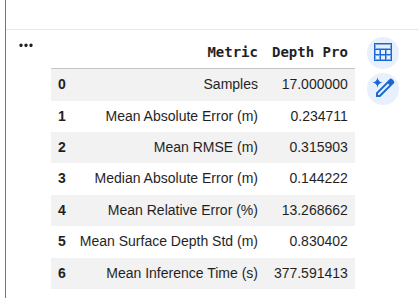

## Interpretation

The evaluation demonstrates that Depth Pro provides reasonably accurate monocular metric-depth estimation in the tested real-world indoor environment. Across 17 evaluated samples, the model achieved a Mean Absolute Error (MAE) of 0.235 m, RMSE of 0.316 m, and Mean Relative Error of 13.27%. The median absolute error of 0.144 m indicates that typical pixel-level errors are substantially lower than the overall RMSE, although some larger errors are present.

For a robotic perception system, these results indicate that Depth Pro can provide useful metric depth from a single RGB camera, potentially supporting applications such as obstacle detection, navigation, and 3D perception without requiring a dedicated depth sensor. However, the mean inference time of 0.378 s per frame (~2.65 FPS) is a significant limitation for real-time robotic operation.

The results should therefore be interpreted as promising but not yet sufficient to claim real-time deployment performance. The experiment is limited to an indoor laboratory environment and a relatively small dataset, and the RealSense sensor itself introduces measurement limitations.

Overall, Depth Pro demonstrates good metric-depth accuracy for the tested environment, but its inference speed and limited experimental scope make further evaluation and optimization necessary before deployment in a real-time autonomous robotic system.

## Limitations

This experiment is a controlled validation study rather than a benchmark.

1. The RealSense depth sensor is treated as the reference measurement and may itself contain sensor noise and invalid pixels.
2. The dataset is limited to a real indoor laboratory environment.
3. The number of RGB-depth pairs is limited to 59 samples.
4. RealSense depth quality can degrade for reflective, transparent, distant, or low-texture surfaces.
5. Accurate RGB-depth alignment is required for reliable pixel-level evaluation.
6. Frames were captured as single, independent samples across varying depths rather than repeated captures at fixed distances, so classical repeatability could not be evaluated; per-frame spatial consistency is used instead.
7. Focal-length evaluation is descriptive unless an independently calibrated camera focal length is available.
8. Established datasets such as NYUv2, KITTI, and other metric-depth benchmarks are required for broader model comparison.

The real dataset is therefore most useful for evaluating model behavior in the intended robotic sensing setup.


## Conclusion

This notebook establishes a workflow for evaluating Depth Pro as a monocular metric-depth estimator against dense, real-world ground truth.

The complete pipeline is:

**RealSense RGB-depth pair → RGB image → Depth Pro → dense metric depth → pixel-level comparison against RealSense depth → statistical analysis → accuracy evaluation**

The dense RealSense depth maps provide independent metric ground truth for all 59 frames, enabling pixel-level accuracy analysis in addition to image-level median-depth comparison. The same test protocol can be used directly with other metric-depth models, allowing Depth Pro, ZoeDepth, and Depth-Anything-V2 to be compared using identical RGB-depth pairs and evaluation metrics.


## Experimental Extension

Extending the dataset only requires adding more `color/` + `depth/` RGB-depth pairs to the zip uploaded on Hugging Face, following the same filename-aligned structure.

The evaluation code, metrics, plots, aggregation, and analysis can remain unchanged.

This makes the notebook suitable for extending the experiment to additional scenes, viewpoints, lighting conditions, and target hardware.
